##Лабораторная работа №4

In [1]:
!pip install "dask[complete]" graphviz pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00


In [3]:
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar
from IPython.display import display, Image


##Задание 4.1. Построение ETL-пайплайна средствами Dask:


##Extract:

In [4]:
client = Client(n_workers=1, threads_per_worker=2, processes=True)
display(client)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42205
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44715'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34313 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34313
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:38856
INFO:distributed.scheduler:Receive client connection: Client-7bfaa9e6-324e-11f1-85e2-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:38860


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42205,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34313,Total threads: 2
Dashboard: http://127.0.0.1:34243/status,Memory: 12.67 GiB
Nanny: tcp://127.0.0.1:44715,


In [6]:
file_path = "parking_2017.csv"
df = dd.read_csv(file_path, dtype=str, assume_missing=True)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
npartitions=6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [7]:
print("Количество партиций:", df.npartitions)
print("Список столбцов:")
print(df.columns.tolist())

Количество партиций: 6
Список столбцов:
['Summons Number', 'Plate ID', 'Registration State', 'Plate Type', 'Issue Date', 'Violation Code', 'Vehicle Body Type', 'Vehicle Make', 'Issuing Agency', 'Street Code1', 'Street Code2', 'Street Code3', 'Vehicle Expiration Date', 'Violation Location', 'Violation Precinct', 'Issuer Precinct', 'Issuer Code', 'Issuer Command', 'Issuer Squad', 'Violation Time', 'Time First Observed', 'Violation County', 'Violation In Front Of Or Opposite', 'House Number', 'Street Name', 'Intersecting Street', 'Date First Observed', 'Law Section', 'Sub Division', 'Violation Legal Code', 'Days Parking In Effect    ', 'From Hours In Effect', 'To Hours In Effect', 'Vehicle Color', 'Unregistered Vehicle?', 'Vehicle Year', 'Meter Number', 'Feet From Curb', 'Violation Post Code', 'Violation Description', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation']


In [8]:
df.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,GY,<NA>,2001,<NA>,0,<NA>,FAILURE TO STOP AT RED LIGHT,<NA>,<NA>,<NA>
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,GY,<NA>,2001,<NA>,0,<NA>,FAILURE TO STOP AT RED LIGHT,<NA>,<NA>,<NA>
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,BK,<NA>,2004,<NA>,0,<NA>,BUS LANE VIOLATION,<NA>,<NA>,<NA>
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,WH,<NA>,2007,<NA>,0,04,47-Double PKG-Midtown,<NA>,<NA>,<NA>
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,WHITE,<NA>,2007,<NA>,0,31 6,69-Failure to Disp Muni Recpt,<NA>,<NA>,<NA>


##Transform:

In [9]:
missing_values = df.isnull().sum()
mysize = df.index.size
missing_count = (missing_values / mysize) * 100

with ProgressBar():
    missing_count_percent = missing_count.compute()

print(missing_count_percent)

Summons Number                         0.000000
Plate ID                               0.006087
Registration State                     0.000000
Plate Type                             0.000000
Issue Date                             0.000000
Violation Code                         0.000000
Vehicle Body Type                      0.385231
Vehicle Make                           0.662839
Issuing Agency                         0.000000
Street Code1                           0.000000
Street Code2                           0.000000
Street Code3                           0.000000
Vehicle Expiration Date                0.000000
Violation Location                    18.508519
Violation Precinct                     0.000000
Issuer Precinct                        0.000000
Issuer Code                            0.000000
Issuer Command                        18.422272
Issuer Squad                          18.430869
Violation Time                         0.000465
Time First Observed                   92

In [10]:
columns_to_drop = list(missing_count_percent[missing_count_percent > 60].index)
print("Удаляемые столбцы:", columns_to_drop)

Удаляемые столбцы: ['Time First Observed', 'Intersecting Street', 'Violation Legal Code', 'Unregistered Vehicle?', 'Meter Number', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation']


In [11]:
df_dropped = df.drop(columns=columns_to_drop)
df_dropped

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Date First Observed,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
npartitions=6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [12]:
df_dropped.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,1111,D,<NA>,<NA>,<NA>,GY,2001,0,<NA>,FAILURE TO STOP AT RED LIGHT
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,1111,D,<NA>,<NA>,<NA>,GY,2001,0,<NA>,FAILURE TO STOP AT RED LIGHT
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,1111,C,<NA>,<NA>,<NA>,BK,2004,0,<NA>,BUS LANE VIOLATION
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,408,l2,Y,0700A,0700P,WH,2007,0,04,47-Double PKG-Midtown
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,408,h1,Y,0700A,0700P,WHITE,2007,0,31 6,69-Failure to Disp Muni Recpt


In [13]:
print("Количество столбцов до очистки:", len(df.columns))
print("Количество столбцов после очистки:", len(df_dropped.columns))

Количество столбцов до очистки: 43
Количество столбцов после очистки: 35


##Load:

In [14]:
df_dropped.to_parquet("cleaned_dataset.parquet", engine="pyarrow")
print("Очищенный датасет сохранен в cleaned_dataset.parquet")

Очищенный датасет сохранен в cleaned_dataset.parquet


In [15]:
!zip -r cleaned_dataset.zip cleaned_dataset.parquet

  adding: cleaned_dataset.parquet/ (stored 0%)
  adding: cleaned_dataset.parquet/part.4.parquet (deflated 21%)
  adding: cleaned_dataset.parquet/part.5.parquet (deflated 21%)
  adding: cleaned_dataset.parquet/part.2.parquet (deflated 21%)
  adding: cleaned_dataset.parquet/part.0.parquet (deflated 21%)
  adding: cleaned_dataset.parquet/part.3.parquet (deflated 21%)
  adding: cleaned_dataset.parquet/part.1.parquet (deflated 21%)


In [16]:
files.download("cleaned_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Задание 4.2. Визуализация DAG:

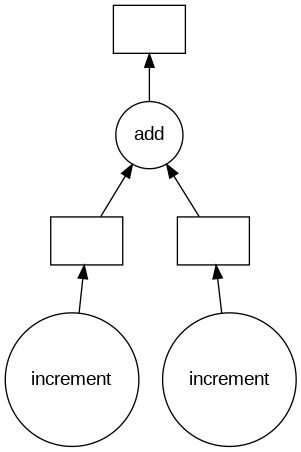

In [17]:
def increment(i):
    return i + 1

def add(x, y):
    return x + y

x = delayed(increment)(1)
y = delayed(increment)(2)
z = delayed(add)(x, y)

z.visualize(filename="simple_dag", format="png")
Image("simple_dag.png")

In [18]:
print("Результат вычисления DAG:", z.compute())

Результат вычисления DAG: 5


## 4.2.2. Визуализация многоуровневого DAG

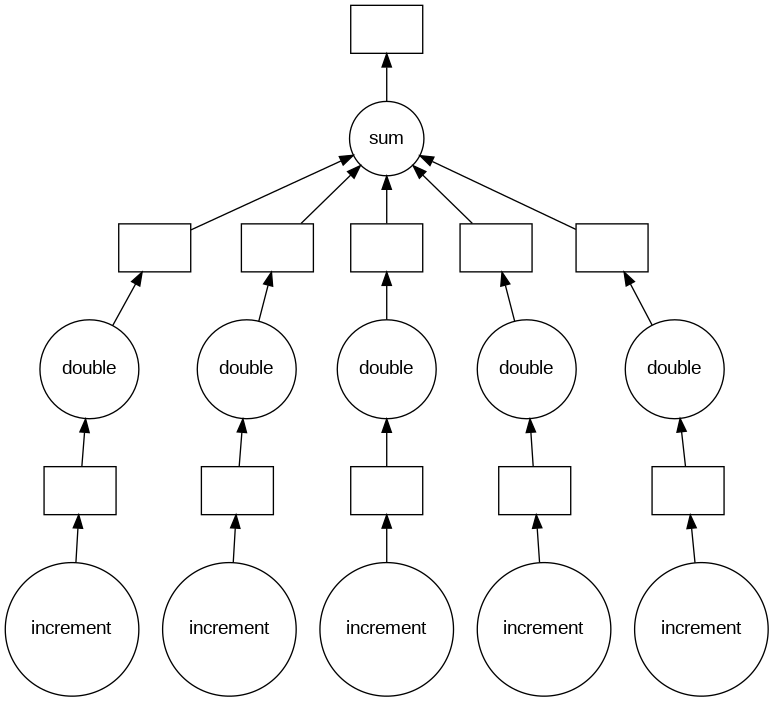

In [19]:
data = [1, 2, 3, 4, 5]

layer1 = [delayed(increment)(i) for i in data]

def double(x):
    return x * 2

layer2 = [delayed(double)(j) for j in layer1]

total2 = delayed(sum)(layer2)

total2.visualize(filename="complex_dag", format="png")
Image("complex_dag.png")

In [20]:
result = total2.compute()
print("Итоговый результат:", result)

Итоговый результат: 40


##Вывод:


В ходе выполнения лабораторной работы был реализован ETL-конвейер с использованием библиотеки Dask для обработки большого объема данных. Выполнена ленивaя загрузка исходного CSV-файла, что позволило избежать переполнения оперативной памяти. Проведен анализ качества данных, рассчитаны проценты пропущенных значений и выполнено удаление столбцов с высокой долей пропусков с использованием принципа ленивых вычислений.

Очищенный датасет успешно сохранен на диск в формате Parquet, что подтверждает завершение этапа Load. Также были построены и визуализированы направленные ациклические графы (DAG), демонстрирующие механизм формирования и выполнения задач в Dask.

Таким образом, в работе были закреплены навыки построения ETL-пайплайнов, понимание принципов lazy evaluation и роли DAG в оптимизации вычислений при работе с большими данными.
